# Task: Selecting Kernel Parameters

Try running the code with different σ in x and y directions, e.g., σ=1 in x and 6 in y. Experiment with varying the truncate parameter to adjust window size. Gaussian smoothing is often used to remove random noise in images. For other types of noise, like "salt and pepper," a median filter is typically applied.  Check the `skimage.filters` documentation for a list of available filters. Try a median filter and compare the results.

In [428]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import output
output.enable_custom_widget_manager()
import glob
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


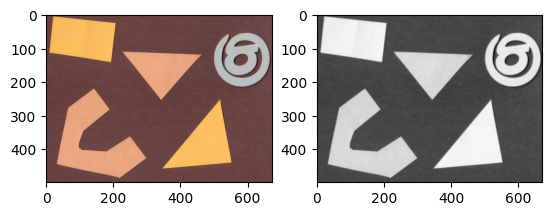

In [429]:
%matplotlib inline

# load the image
shapes01 = iio.imread(uri="/content/drive/MyDrive/Colab Notebooks/images/shapes-02.jpg")

# convert the image to grayscale
gray_shapes = ski.color.rgb2gray(shapes01)

# blur the image to denoise
blurred_shapes = ski.filters.gaussian(gray_shapes, sigma=1.0)

fig, ax = plt.subplots(1,2)
ax[0].imshow(shapes01)
ax[1].imshow(blurred_shapes, cmap="gray")

(0.0, 1.0)

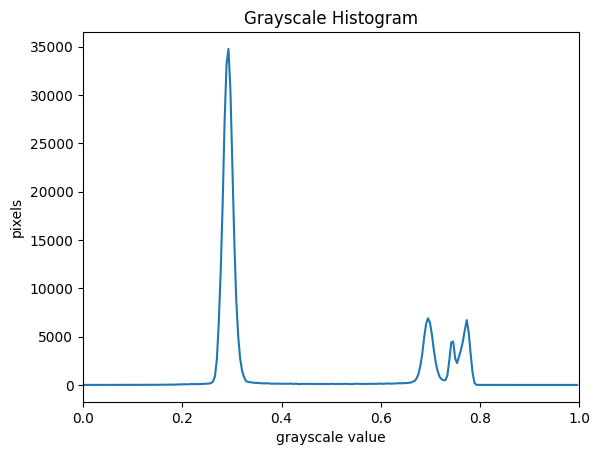

In [430]:
# create a histogram of the blurred grayscale image
histogram, bin_edges = np.histogram(blurred_shapes, bins=256, range=(0.0, 1.0))

fig, ax = plt.subplots()

ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Grayscale Histogram")
ax.set_xlabel("grayscale value")
ax.set_ylabel("pixels")
ax.set_xlim(0, 1.0)

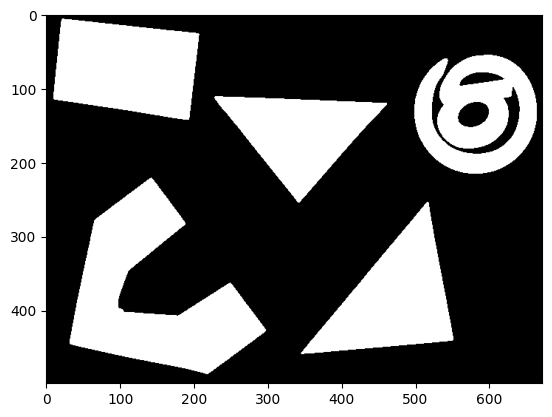

In [431]:
# create a mask based on the threshold
t = 0.4
binary_mask = blurred_shapes > t
fig, ax = plt.subplots()
ax.imshow(binary_mask, cmap="gray")

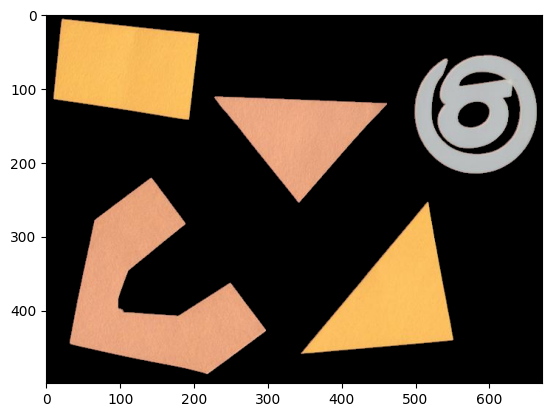

In [432]:
# use the binary_mask to select the "interesting" part of the image
selection = shapes01.copy()
selection[~binary_mask] = 0
fig, ax = plt.subplots()
ax.imshow(selection)

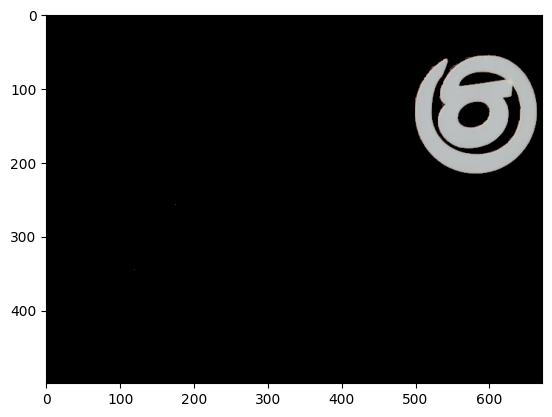

In [433]:
shapes01 = shapes01/255.0 if shapes01.dtype == np.uint8 else shapes01
t=shapes01.max(axis=2)-shapes01.min(axis=2)

binary_mask = (t<0.12)& (shapes01.mean(axis=2)>0.35)

selection = shapes01.copy()
selection[~binary_mask] = 0
fig, ax = plt.subplots()
ax.imshow(selection)

# Automatic Segmentation
The disadvantage of simple thresholding techniques is that you have to manually determine the threshold t each time by analyzing the histogram. There are also automatic thresholding methods that can determine the threshold value automatically. One such method is Otsu method. It is especially useful when the grayscale histogram of the image has two peaks corresponding to the background and the objects of interest.

Removing image noise before thresholding
In practice, it is often necessary to remove noise from the image before applying thresholding. This can be done using one of the blurring methods.

Let’s load the image and blur it using a Gaussian filter with σ = 1.

In [434]:
import cv2
def connected_components(filename, sigma=1.0, t=0.5, connectivity=2):
  maize_roots = iio.imread(uri=filename)
  # convert the image to grayscale
  gray_image = cv2.cvtColor(maize_roots, cv2.COLOR_RGB2GRAY)

  # blur the image to denoise
  blurred_image=cv2.GaussianBlur(gray_image,(5,5),0)
  _, binary= cv2.threshold(
    blurred_image,
    0,
    255,
    cv2.THRESH_BINARY+cv2.THRESH_OTSU
  )


  if np.mean(binary == 255) > 0.5:
    binary=cv2.bitwise_not(binary)

  binary_mask = binary>0
  labeled_image, count = ski.measure.label(
        binary_mask,
        connectivity=connectivity,
        return_num=True
        )

  return binary_mask, labeled_image, count

filename = "/content/drive/MyDrive/Colab Notebooks/images/maize-root-cluster.jpg"

binary_mask, labeled_image, count = connected_components(filename)

regions = ski.measure.regionprops(labeled_image)
largest = max(regions, key=lambda r: r.area)
root_only_mask = (labeled_image == largest.label)

root_mass_ratio = np.count_nonzero(root_only_mask) / root_only_mask.size

print(f"Root mass ratio (root only): {root_mass_ratio:.4f}")


Root mass ratio (root only): 0.1358


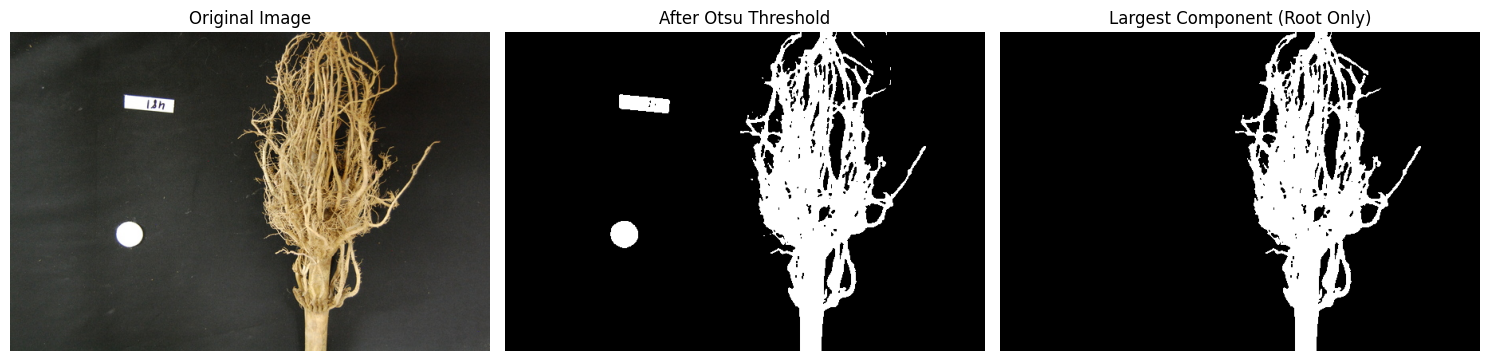

In [435]:
# Load original for display
original = iio.imread(filename)

plt.figure(figsize=(15,5))

# --- Original image ---
plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

# --- Binary after threshold ---
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.title("After Otsu Threshold")
plt.axis("off")

# --- Final cleaned root mask ---

plt.subplot(1,3,3)
plt.imshow(root_only_mask, cmap='gray')
plt.title("Largest Component (Root Only)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Create a binary mask that keeps only the pixels of bacterial colonies and “turns off” all other pixels in the image.


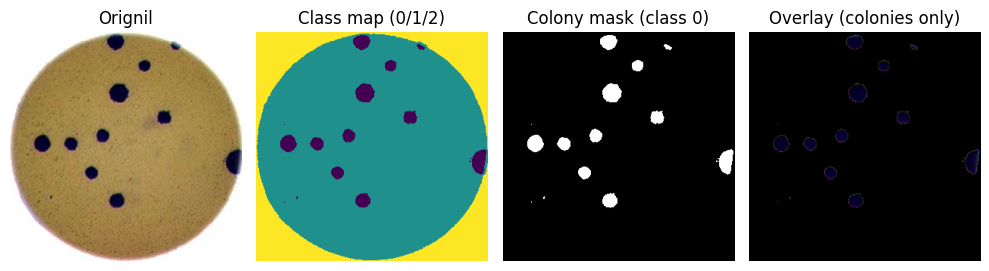

In [475]:
from google.colab.patches import cv2_imshow

colonies = iio.imread(uri='/content/drive/MyDrive/Colab Notebooks/images/colonies-01.tif')

# convert the image to grayscale
gray_image = ski.color.rgb2gray(colonies[:,:,:3])

# blur the image to denoise
blurred_image = ski.filters.gaussian(gray_image, sigma=1.0)

# show the histogram of the blurred image
histogram, bin_edges = np.histogram(blurred_image, bins=256, range=(0.0, 1.0))

# perform automatic thresholding
t = ski.filters.threshold_multiotsu(gray_image, classes=3)
regions = np.digitize(gray_image, bins=t)

# create a binary mask with the threshold found by Otsu's method
# binary_mask = blurred_image >  t
colony_mask = (regions==0)

plate_mask = (regions !=2)
colony_mask= colony_mask & plate_mask
colony_mask_u8 = (colony_mask*255).astype(np.uint8)

selection= colonies.copy()
selection[~colony_mask] = 0

fig, ax = plt.subplots(1, 4, figsize=(10,10))

ax[0].imshow(colonies)
ax[0].set_title("Orignil")
ax[0].axis("off")

ax[1].imshow(regions, cmap="viridis")
ax[1].set_title("Class map (0/1/2)")
ax[1].axis("off")

ax[2].imshow(colony_mask_u8, cmap="gray")
ax[2].set_title("Colony mask (class 0)")
ax[2].axis("off")

ax[3].imshow(selection)
ax[3].set_title("Overlay (colonies only)")
ax[3].axis("off")

plt.tight_layout()
plt.show()